In [1]:
!pip install mesa

In [2]:
import random
import mesa
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import io
import base64

In [3]:
# NEW FEATURE (Restaurant Simulation): Define possible group sizes
GROUP_SIZES = [2, 4, 6]

# NEW FEATURE (Time Slots): Define available dinner times
TIME_SLOTS = ["6:00 PM", "7:00 PM", "8:00 PM", "9:00 PM"]

print("✅ Group sizes:", GROUP_SIZES)
print("✅ Time slots:", TIME_SLOTS)

✅ Group sizes: [2, 4, 6]
✅ Time slots: ['6:00 PM', '7:00 PM', '8:00 PM', '9:00 PM']


In [4]:
class CustomerAgent(Agent):
    """
    A restaurant customer agent.
    Each customer has a group size (2, 4, or 6) and a preferred time slot.
    """
    
    def __init__(self, unique_id, model):
        super().__init__(model)
        self.unique_id = unique_id
        self.booking = 0  # 1 = booked, 0 = not booked
        self.waiting = False
        self.group_size = random.choice(GROUP_SIZES)
        # NEW FEATURE (Time Slots): Assign a random time slot
        self.time_slot = random.choice(TIME_SLOTS)
        self.pos = None
        print(f"👤 Customer {self.unique_id} | Group: {self.group_size} | Time: {self.time_slot}")

    def step(self):
        """
        Each step, the customer tries to find a table.
        They check if the table is occupied by someone with the SAME time slot.
        """
        available_tables = self.model.get_tables_for_size(self.group_size)
        
        if not self.waiting:
            if available_tables:
                table_pos = random.choice(available_tables)
                # NEW FEATURE (Time Slots): Check if anyone with the SAME time slot is at this table
                cell_content = self.model.grid.get_cell_list_contents([table_pos])
                same_time_agents = [a for a in cell_content if a.time_slot == self.time_slot]
                
                if len(same_time_agents) == 0:
                    # Success! No one with this time slot is at the table
                    self.model.grid.move_agent(self, table_pos)
                    self.booking = 1
                    self.waiting = False
                    print(f"✅ Customer {self.unique_id} ({self.time_slot}) booked table at {table_pos}")
                else:
                    # Table is taken for this time slot
                    self.waiting = True
                    print(f"❌ Customer {self.unique_id} ({self.time_slot}) – table taken. Waiting...")
            else:
                self.waiting = True
                print(f"❌ Customer {self.unique_id} – no table of size {self.group_size}. Waiting...")
        else:
            # Waiting – try again
            if available_tables:
                table_pos = random.choice(available_tables)
                cell_content = self.model.grid.get_cell_list_contents([table_pos])
                same_time_agents = [a for a in cell_content if a.time_slot == self.time_slot]
                
                if len(same_time_agents) == 0:
                    self.model.grid.move_agent(self, table_pos)
                    self.booking = 1
                    self.waiting = False
                    print(f"✅✅ Customer {self.unique_id} FINALLY booked table at {table_pos} from waiting list!")
                else:
                    print(f"⏳ Customer {self.unique_id} still waiting...")
            else:
                print(f"⏳ Customer {self.unique_id} still waiting (no table size)...")

In [5]:
class RestaurantModel(Model):
    """
    The main restaurant model.
    Manages the grid, tables, and customers.
    """
    
    def __init__(self, num_agents, grid_width, grid_height,
                 num_tables_2=3, num_tables_4=3, num_tables_6=2):
        super().__init__()
        self.num_agents = num_agents
        self.grid = MultiGrid(grid_width, grid_height, True)
        self._agents = []  # All agents
        self.tables = []   # List of (position, size)

        # Place tables in the bottom half of the grid
        available_cells = []
        for x in range(grid_width):
            for y in range(grid_height // 2, grid_height):
                available_cells.append((x, y))
        random.shuffle(available_cells)
        
        idx = 0
        for size, count in [(2, num_tables_2), (4, num_tables_4), (6, num_tables_6)]:
            for _ in range(count):
                if idx < len(available_cells):
                    pos = available_cells[idx]
                    idx += 1
                    self.tables.append((pos, size))
                    print(f"📊 Placed {size}-seat table at {pos}")

        # Create customer agents
        for i in range(self.num_agents):
            a = CustomerAgent(i, self)
            # Place customers in the top half of the grid (waiting area)
            x = random.randrange(self.grid.width)
            y = random.randrange(0, self.grid.height // 2)
            self.grid.place_agent(a, (x, y))
            a.pos = (x, y)
            self._agents.append(a)

        # NEW FEATURE (Time Slots): Data collector tracks bookings per time slot
        self.datacollector = DataCollector(
            model_reporters={
                "Occupied Tables": lambda m: sum(1 for a in m._agents if a.booking == 1),
                "Waiting Customers": lambda m: sum(1 for a in m._agents if a.waiting),
                # NEW FEATURE (Time Slots): Count bookings for each time slot
                "6:00 PM Booked": lambda m: sum(1 for a in m._agents if a.booking == 1 and a.time_slot == "6:00 PM"),
                "7:00 PM Booked": lambda m: sum(1 for a in m._agents if a.booking == 1 and a.time_slot == "7:00 PM"),
                "8:00 PM Booked": lambda m: sum(1 for a in m._agents if a.booking == 1 and a.time_slot == "8:00 PM"),
                "9:00 PM Booked": lambda m: sum(1 for a in m._agents if a.booking == 1 and a.time_slot == "9:00 PM"),
            },
            agent_reporters={
                "Booking": "booking",
                "Group Size": "group_size",
                "Waiting": "waiting",
                "Time Slot": "time_slot"  # NEW: Track time slot per agent
            }
        )

    def get_tables_for_size(self, group_size):
        """
        Return a list of table positions that can fit the group.
        A table fits if its capacity >= group_size.
        """
        return [pos for pos, size in self.tables if size >= group_size]

    def step(self):
        """Run one step of the simulation."""
        self.datacollector.collect(self)
        agents = self._agents.copy()
        random.shuffle(agents)
        for agent in agents:
            agent.step()

In [6]:
def draw_restaurant_grid(model):
    """
    Draw the restaurant grid showing tables and customers.
    NEW FEATURE (Time Slots): Different colors for each time slot.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw the grid lines
    for x in range(model.grid.width):
        for y in range(model.grid.height):
            rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='lightgray', facecolor='none')
            ax.add_patch(rect)
    
    # Draw tables
    for (x, y), size in model.tables:
        color = {2: 'lightblue', 4: 'lightgreen', 6: 'lightyellow'}.get(size, 'white')
        rect = patches.Rectangle((x + 0.05, y + 0.05), 0.9, 0.9, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, f'{size}p', fontsize=10, ha='center', va='center', fontweight='bold')
    
    # NEW FEATURE (Time Slots): Colors for each time slot
    time_colors = {
        "6:00 PM": "purple",
        "7:00 PM": "cyan",
        "8:00 PM": "magenta",
        "9:00 PM": "gold"
    }
    
    # Draw customers
    for agent in model._agents:
        x, y = agent.pos
        if agent.booking == 1:
            # Booked – color depends on time slot
            color = time_colors.get(agent.time_slot, "green")
            label = f'{agent.group_size}'
        else:
            # Waiting – red
            color = 'red'
            label = 'W'
        ax.plot(x + 0.5, y + 0.5, 'o', color=color, markersize=15)
        ax.text(x + 0.5, y + 0.5, label, fontsize=8, ha='center', va='center', color='white', fontweight='bold')
    
    ax.set_xlim(0, model.grid.width)
    ax.set_ylim(0, model.grid.height)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title("Restaurant Table Booking - Colors by Time Slot", fontsize=14)
    
    # Update legend with time slot colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightblue', label='2-seat table'),
        Patch(facecolor='lightgreen', label='4-seat table'),
        Patch(facecolor='lightyellow', label='6-seat table'),
        Patch(facecolor='purple', label='6:00 PM'),
        Patch(facecolor='cyan', label='7:00 PM'),
        Patch(facecolor='magenta', label='8:00 PM'),
        Patch(facecolor='gold', label='9:00 PM'),
        Patch(facecolor='red', label='Waiting customer')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.show()

=== Starting Restaurant Simulation with Time Slots ===

📊 Placed 2-seat table at (8, 6)
📊 Placed 2-seat table at (8, 9)
📊 Placed 2-seat table at (0, 5)
📊 Placed 2-seat table at (0, 7)
📊 Placed 4-seat table at (5, 9)
📊 Placed 4-seat table at (2, 7)
📊 Placed 4-seat table at (0, 9)
📊 Placed 6-seat table at (3, 8)
📊 Placed 6-seat table at (3, 6)
👤 Customer 0 | Group: 6 | Time: 9:00 PM
👤 Customer 1 | Group: 2 | Time: 7:00 PM
👤 Customer 2 | Group: 2 | Time: 9:00 PM
👤 Customer 3 | Group: 4 | Time: 7:00 PM
👤 Customer 4 | Group: 6 | Time: 7:00 PM
👤 Customer 5 | Group: 2 | Time: 7:00 PM
👤 Customer 6 | Group: 4 | Time: 6:00 PM
👤 Customer 7 | Group: 6 | Time: 8:00 PM
👤 Customer 8 | Group: 2 | Time: 8:00 PM
👤 Customer 9 | Group: 6 | Time: 6:00 PM
👤 Customer 10 | Group: 4 | Time: 9:00 PM
👤 Customer 11 | Group: 6 | Time: 8:00 PM
👤 Customer 12 | Group: 2 | Time: 6:00 PM
👤 Customer 13 | Group: 6 | Time: 6:00 PM
👤 Customer 14 | Group: 6 | Time: 9:00 PM
👤 Customer 15 | Group: 4 | Time: 6:00 PM
👤 Customer

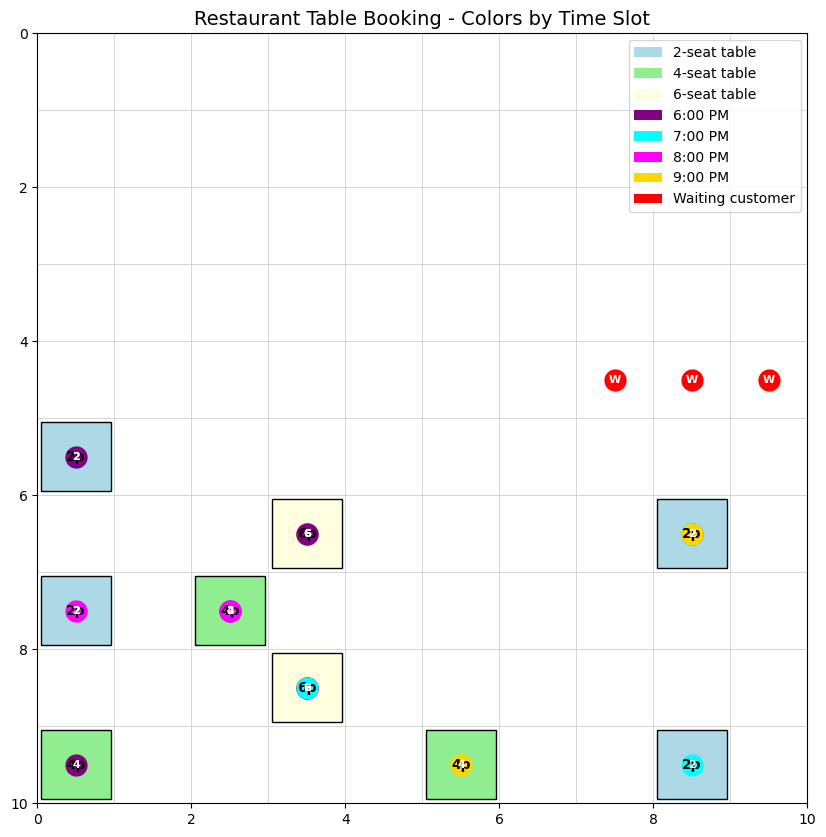

In [7]:
print("=== Starting Restaurant Simulation with Time Slots ===\n")

# Create the restaurant
model = RestaurantModel(
    num_agents=25,
    grid_width=10,
    grid_height=10,
    num_tables_2=4,
    num_tables_4=3,
    num_tables_6=2
)

print("\n--- Running Simulation ---\n")

# Run for 10 steps
for step in range(10):
    model.step()
    occupied = sum(1 for a in model._agents if a.booking == 1)
    waiting = sum(1 for a in model._agents if a.waiting)
    print(f"Step {step+1}: Occupied = {occupied}, Waiting = {waiting}")

# Show final results
print("\n--- Final Data Table ---")
data = model.datacollector.get_model_vars_dataframe()
print(data)

# Draw the final grid
draw_restaurant_grid(model)

In [8]:
%%writefile restaurant_app.py
"""
Restaurant Table Booking Simulation – Web Interface (Solara)
NEW FEATURE (Time Slots): Customers book tables for specific time periods.
"""

import solara
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np
from mesa.space import MultiGrid
import io
import base64

# ---------- Simulation Code ----------
GROUP_SIZES = [2, 4, 6]
TIME_SLOTS = ["6:00 PM", "7:00 PM", "8:00 PM", "9:00 PM"]

class CustomerAgent:
    def __init__(self, unique_id, model):
        self.unique_id = unique_id
        self.model = model
        self.booking = 0
        self.waiting = False
        self.group_size = random.choice(GROUP_SIZES)
        self.time_slot = random.choice(TIME_SLOTS)
        self.pos = None

    def step(self):
        available_tables = self.model.get_tables_for_size(self.group_size)
        
        if not self.waiting:
            if available_tables:
                table_pos = random.choice(available_tables)
                cell_content = self.model.grid.get_cell_list_contents([table_pos])
                same_time_agents = [a for a in cell_content if a.time_slot == self.time_slot]
                if len(same_time_agents) == 0:
                    self.model.grid.move_agent(self, table_pos)
                    self.booking = 1
                    self.waiting = False
                else:
                    self.waiting = True
            else:
                self.waiting = True
        else:
            if available_tables:
                table_pos = random.choice(available_tables)
                cell_content = self.model.grid.get_cell_list_contents([table_pos])
                same_time_agents = [a for a in cell_content if a.time_slot == self.time_slot]
                if len(same_time_agents) == 0:
                    self.model.grid.move_agent(self, table_pos)
                    self.booking = 1
                    self.waiting = False

class RestaurantModel:
    def __init__(self, num_agents, grid_width, grid_height,
                 num_tables_2=3, num_tables_4=3, num_tables_6=2):
        self.num_agents = num_agents
        self.grid = MultiGrid(grid_width, grid_height, True)
        self._agents = []
        self.tables = []

        available_cells = [(x, y) for x in range(grid_width) for y in range(grid_height//2, grid_height)]
        random.shuffle(available_cells)
        idx = 0
        for size, count in [(2, num_tables_2), (4, num_tables_4), (6, num_tables_6)]:
            for _ in range(count):
                if idx < len(available_cells):
                    pos = available_cells[idx]
                    idx += 1
                    self.tables.append((pos, size))

        for i in range(self.num_agents):
            a = CustomerAgent(i, self)
            x = random.randrange(self.grid.width)
            y = random.randrange(0, self.grid.height//2)
            self.grid.place_agent(a, (x, y))
            a.pos = (x, y)
            self._agents.append(a)

    def get_tables_for_size(self, group_size):
        return [pos for pos, size in self.tables if size >= group_size]

    def step(self):
        agents = self._agents.copy()
        random.shuffle(agents)
        for agent in agents:
            agent.step()

    def get_stats(self):
        total = len(self._agents)
        booked = sum(1 for a in self._agents if a.booking == 1)
        waiting = sum(1 for a in self._agents if a.waiting)
        return total, booked, waiting

# ---------- Visualization ----------
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)
    return f"data:image/png;base64,{img_base64}"

def draw_restaurant_image(model):
    fig, ax = plt.subplots(figsize=(8, 8))
    for x in range(model.grid.width):
        for y in range(model.grid.height):
            rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='lightgray', facecolor='none')
            ax.add_patch(rect)
    
    for (x, y), size in model.tables:
        color = {2: 'lightblue', 4: 'lightgreen', 6: 'lightyellow'}.get(size, 'white')
        rect = patches.Rectangle((x + 0.05, y + 0.05), 0.9, 0.9, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, f'{size}p', fontsize=10, ha='center', va='center', fontweight='bold')
    
    time_colors = {"6:00 PM": "purple", "7:00 PM": "cyan", "8:00 PM": "magenta", "9:00 PM": "gold"}
    for agent in model._agents:
        x, y = agent.pos
        if agent.booking == 1:
            color = time_colors.get(agent.time_slot, "green")
            label = f'{agent.group_size}'
        else:
            color = 'red'
            label = 'W'
        ax.plot(x + 0.5, y + 0.5, 'o', color=color, markersize=15)
        ax.text(x + 0.5, y + 0.5, label, fontsize=8, ha='center', va='center', color='white', fontweight='bold')
    
    ax.set_xlim(0, model.grid.width)
    ax.set_ylim(0, model.grid.height)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title("Restaurant Table Booking - Colors by Time Slot", fontsize=14)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightblue', label='2-seat table'),
        Patch(facecolor='lightgreen', label='4-seat table'),
        Patch(facecolor='lightyellow', label='6-seat table'),
        Patch(facecolor='purple', label='6:00 PM'),
        Patch(facecolor='cyan', label='7:00 PM'),
        Patch(facecolor='magenta', label='8:00 PM'),
        Patch(facecolor='gold', label='9:00 PM'),
        Patch(facecolor='red', label='Waiting')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    img_src = fig_to_base64(fig)
    return img_src

# ---------- ATTRACTIVE SOLARA WEB INTERFACE (Visible Gray Transparent Sidebar) ----------
@solara.component
def Page():
    num_agents, set_num_agents = solara.use_state(20)
    width, set_width = solara.use_state(10)
    height, set_height = solara.use_state(10)
    steps, set_steps = solara.use_state(10)
    tables_2, set_tables_2 = solara.use_state(4)
    tables_4, set_tables_4 = solara.use_state(3)
    tables_6, set_tables_6 = solara.use_state(2)
    results, set_results = solara.use_state(None)
    img_src, set_img_src = solara.use_state(None)

    def run_simulation():
        m = RestaurantModel(
            num_agents=num_agents,
            grid_width=width,
            grid_height=height,
            num_tables_2=tables_2,
            num_tables_4=tables_4,
            num_tables_6=tables_6
        )
        for _ in range(steps):
            m.step()
        total, booked, waiting = m.get_stats()
        set_results((total, booked, waiting))
        set_img_src(draw_restaurant_image(m))

    # UPDATED: Light gray transparent sidebar with blur - more visible
    solara.Style("""
        .sidebar { 
            background: rgba(200, 200, 200, 0.35); 
            backdrop-filter: blur(15px);
            -webkit-backdrop-filter: blur(15px);
            color: #2c3e50; 
            padding: 20px; 
            border-radius: 0 15px 15px 0; 
            height: 100vh; 
            overflow-y: auto; 
            border-right: 2px solid rgba(255,255,255,0.3);
            box-shadow: 4px 0 20px rgba(0,0,0,0.08);
        }
        .sidebar h2, .sidebar h3 {
            color: #2c3e50;
        }
        .sidebar .v-label {
            color: #2c3e50 !important;
            font-weight: 600;
        }
        .sidebar hr {
            border-color: rgba(44, 62, 80, 0.2);
        }
        .result-card { background: white; border-radius: 12px; padding: 15px; margin: 10px 0; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
        .main-content { background: #f0f2f5; }
    """)

    with solara.Row(style={"height": "100vh", "overflow": "hidden"}):
        # Visible gray transparent sidebar
        with solara.Column(style={"width": "380px", "padding": "20px", "background": "rgba(200, 200, 200, 0.35)", "backdrop-filter": "blur(15px)", "color": "#2c3e50", "overflow-y": "auto", "flex-shrink": "0", "border-right": "2px solid rgba(255,255,255,0.3)", "box-shadow": "4px 0 20px rgba(0,0,0,0.08)"}):
            solara.Markdown("## 🍽️ Restaurant Controls")
            solara.Markdown("---")
            solara.SliderInt(label="👥 Customers", value=num_agents, min=5, max=50, step=1, on_value=set_num_agents)
            solara.SliderInt(label="📐 Grid Width", value=width, min=5, max=20, step=1, on_value=set_width)
            solara.SliderInt(label="📐 Grid Height", value=height, min=5, max=20, step=1, on_value=set_height)
            solara.Markdown("---")
            solara.Markdown("### 🪑 Table Counts")
            solara.SliderInt(label="2-Seat Tables", value=tables_2, min=0, max=10, step=1, on_value=set_tables_2)
            solara.SliderInt(label="4-Seat Tables", value=tables_4, min=0, max=10, step=1, on_value=set_tables_4)
            solara.SliderInt(label="6-Seat Tables", value=tables_6, min=0, max=10, step=1, on_value=set_tables_6)
            solara.Markdown("---")
            solara.SliderInt(label="⚡ Steps", value=steps, min=1, max=20, step=1, on_value=set_steps)
            solara.Markdown("---")
            solara.Button("▶ Run Simulation", on_click=run_simulation, color="primary", style={"width": "100%", "border-radius": "30px", "padding": "12px", "font-weight": "bold"})

        # Main content
        with solara.Column(style={"flex": "1", "padding": "20px", "background": "#f0f2f5", "overflow-y": "auto"}):
            solara.Markdown("## 📊 Simulation Results")
            if results is not None:
                total, booked, waiting = results
                with solara.Row():
                    with solara.Column(style={"flex": "1"}):
                        solara.Markdown(f"""
                        <div class="result-card" style="background: #d4edda; border-left: 5px solid #28a745;">
                            <h3 style="margin:0;">✅ Booked</h3>
                            <p style="font-size:24px; font-weight:bold; margin:5px 0;">{booked}</p>
                            <p>{booked/total*100:.1f}%</p>
                        </div>
                        """)
                    with solara.Column(style={"flex": "1"}):
                        solara.Markdown(f"""
                        <div class="result-card" style="background: #f8d7da; border-left: 5px solid #dc3545;">
                            <h3 style="margin:0;">⏳ Waiting</h3>
                            <p style="font-size:24px; font-weight:bold; margin:5px 0;">{waiting}</p>
                            <p>{waiting/total*100:.1f}%</p>
                        </div>
                        """)
                    with solara.Column(style={"flex": "1"}):
                        solara.Markdown(f"""
                        <div class="result-card" style="background: #cce5ff; border-left: 5px solid #007bff;">
                            <h3 style="margin:0;">👥 Total</h3>
                            <p style="font-size:24px; font-weight:bold; margin:5px 0;">{total}</p>
                        </div>
                        """)
            else:
                solara.Markdown('<div class="result-card" style="text-align:center; padding:40px;"><p style="font-size:18px;">👈 Adjust sliders and press <strong>Run Simulation</strong></p></div>')

            if img_src is not None:
                solara.Markdown(f'<img src="{img_src}" style="max-width:100%; height:auto; border-radius:12px; box-shadow: 0 4px 12px rgba(0,0,0,0.15); margin-top:20px;" />')

Overwriting restaurant_app.py


In [9]:
!pip install solara

In [ ]:
!solara run restaurant_app.py --port=9005